In [1]:
import numpy as np
import scipy.stats as sps

import glob as glob
import pickle
import sys
import re

import torch
from ili.utils.ndes_pt import LampeEnsemble
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage
from torch_geometric.data import Data as PYGData

import matplotlib.pyplot as plt

2026-04-29 16:50:48.413098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777495848.745086   13907 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777495848.773542   13907 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 16:50:49.950566: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Need these things for the model to even unpickle the posterior pickle
sys.path.insert(0, '/home/puehlengt/ltu-ili/notebooks/ambe_fits')

'''
# 3 parameter model
# from train_deepset import DeepSet, GraphData, apt_param_config
PREBUILT_PATH = '/home/puehlengt/appletree/notebooks/pyg_dataset_raw_3params.pt'
RAW_PATH      = '/home/puehlengt/appletree/notebooks/harvested_testsims_3params.npy'
#'''

# 6 parameter model
from train_hybrid5_deepset_6params import Hybrid5DeepSet, PyGBatchWrapper, GraphData, make_summary, apt_param_config
PREBUILT_PATH = '/home/puehlengt/appletree/notebooks/pyg_dataset_raw_6params.pt'
RAW_PATH      = '/home/puehlengt/appletree/notebooks/harvested_testsims_6params.npy'

In [3]:
ultimate_fbase = '/home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/'
fbase = f'{ultimate_fbase}/500totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau'

# Load posterior (which contains the theta_transform)
with open(f'{fbase}/posterior.pkl', 'rb') as f:
    ensemble = pickle.load(f)
base_model = ensemble.posteriors[0] # architecture + original final weights + theta_transform + prior
base_model.eval()

LampeNPE(
  (nde): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [0, 1, 2, 3, 4, 5]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=19, out_features=64, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=64, out_features=138, bias=True)
          )
        )
        (1): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [5, 4, 3, 2, 1, 0]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=19, out_features=64, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=64, out_features=138, bias=True)
          )
        )
        (2)

In [4]:
fchkpt = '50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau'

path_bag = glob.glob(f'{ultimate_fbase}/{fchkpt}/checkpoint_epoch*.pt')
path_bag.sort(key=lambda p: int(re.search(r'epoch(\d+)', p).group(1)))

epochs_available = [int(re.search(r'epoch(\d+)', p).group(1)) for p in path_bag]
print('Available epochs:', epochs_available)

Available epochs: [100, 200, 300]


In [5]:
#SELECT_EPOCH = epochs_available[-1]
SELECT_EPOCH = 300 # change to any epoch from the list above

ckpt_path = path_bag[epochs_available.index(SELECT_EPOCH)]
base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
base_model.eval()
print(f'Loaded epoch {SELECT_EPOCH}: {ckpt_path}')

Loaded epoch 300: /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep//50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau/checkpoint_epoch300.pt


/tmp/ipykernel_13907/372107712.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))


In [6]:
# Load test data
N_OBS = 1000

num_samples = int(re.search(r'(\d+)totalsamples', fchkpt).group(1))

# Load norm stats (from training data) for test set normalization
with open(f'{ultimate_fbase}/{fchkpt}/norm_stats.pkl', 'rb') as f:
    norm_stats = pickle.load(f)

# Load test data
if torch.os.path.exists(PREBUILT_PATH):
    full = torch.load(PREBUILT_PATH)
    raw_test = list(full[num_samples:num_samples + N_OBS])
else:
    aa = np.load(RAW_PATH, allow_pickle=True).item()
    param_bag, events_bag = aa['param_bag'], aa['events_bag']
    raw_test = [
        PYGData(
            x=torch.tensor(events_bag[i].T),
            y=torch.tensor([v for v in param_bag[i].values()]).reshape(1, -1),
        )
        for i in range(num_samples, num_samples + N_OBS)
    ]

# Compute and z-norm summary stats for test data (6-param model only)
all_summaries_test = np.stack([make_summary(d) for d in raw_test])
summary_norm_test  = torch.tensor(
    (all_summaries_test - norm_stats['summary_mean']) / norm_stats['summary_std'],
    dtype=torch.float32
)

test_graph = GraphData(raw_test, norm_stats['events_mean'], norm_stats['events_std'], summary_norm_test)

# param_names in data order — everything (theta tensors, posterior samples) is in data order
_data_param_order = list(np.load(RAW_PATH, allow_pickle=True).item()['param_bag'][0].keys())
param_names = _data_param_order

theta_test = np.array([d.y.numpy().flatten() for d in raw_test])
print(f'num_samples={num_samples}, test set size={len(raw_test)}')
print(f'param order: {param_names}')

/tmp/ipykernel_13907/596121804.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  full = torch.load(PREBUILT_PATH)


num_samples=50000, test set size=1000
param order: ['g1', 'g2', 'alpha', 'beta', 'epsilon', 'ambe_nr_rate']


In [7]:
posterior = LampeEnsemble(posteriors=[base_model],
                          weights=torch.tensor([1.0])) # weights of the different NN in the ensemble

## Marginal posteriors

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:01<00:00, 649.38it/s]


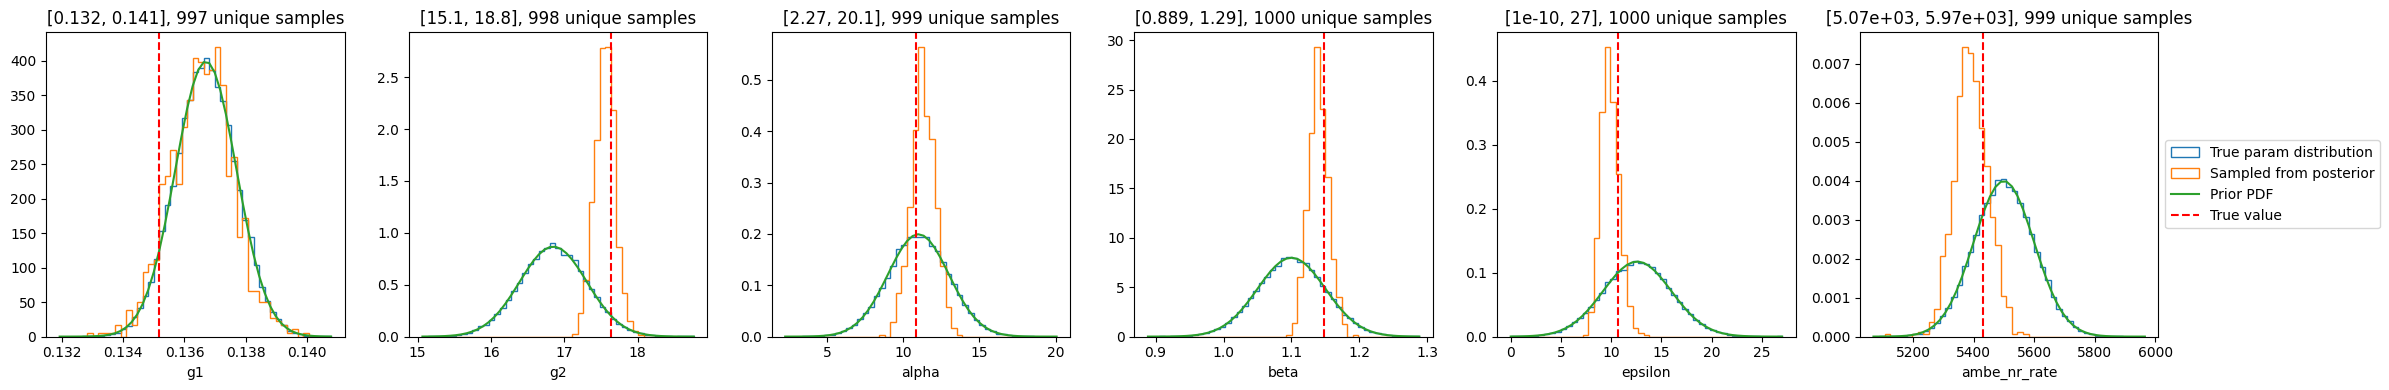

In [8]:
OBS_IDX = 0  # change to look at a different test observation

x_obs = test_graph[OBS_IDX]
y_true = theta_test[OBS_IDX]

torch.manual_seed(1234)
samples = posterior.sample((1000,), x_obs).cpu().numpy()

theta_train = np.array([d.y.numpy().flatten() for d in full[:num_samples]])

n_params = len(param_names)
n_cols   = min(6, n_params)
n_rows   = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = np.array(axes).reshape(n_rows, n_cols)

for _ii, key in enumerate(param_names):
    ax = axes[_ii // n_cols, _ii % n_cols]
    val = apt_param_config[key]

    zzz = theta_train[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 50)
    zzmean = val['prior_args'].get('mean', val['init_mean'])
    zzstd  = val['prior_args'].get('std',  val['init_std'])

    ax.hist(zzz, bins=zzxx, density=True, histtype='step', label='True param distribution')
    ax.hist(samples[:, _ii], bins=zzxx, density=True, histtype='step', label='Sampled from posterior')
    if zzstd > 0:
        ax.plot(zzxx, sps.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    ax.axvline(y_true[_ii], color='red', linestyle='--', label='True value')
    ax.set_title(f'[{zzmin:.3g}, {zzmax:.3g}], {len(np.unique(samples[:, _ii]))} unique samples')
    ax.set_xlabel(key)

axes.flat[n_params - 1].legend(loc='center left', bbox_to_anchor=(1., 0.5))

for _ii in range(n_params, n_rows * n_cols):
    axes.flat[_ii].set_visible(False)

plt.tight_layout()
plt.show()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 12680.65it/s]
INFO:root:Saving single posterior plot to /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/500totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau/plot_single_posterior.jpg...


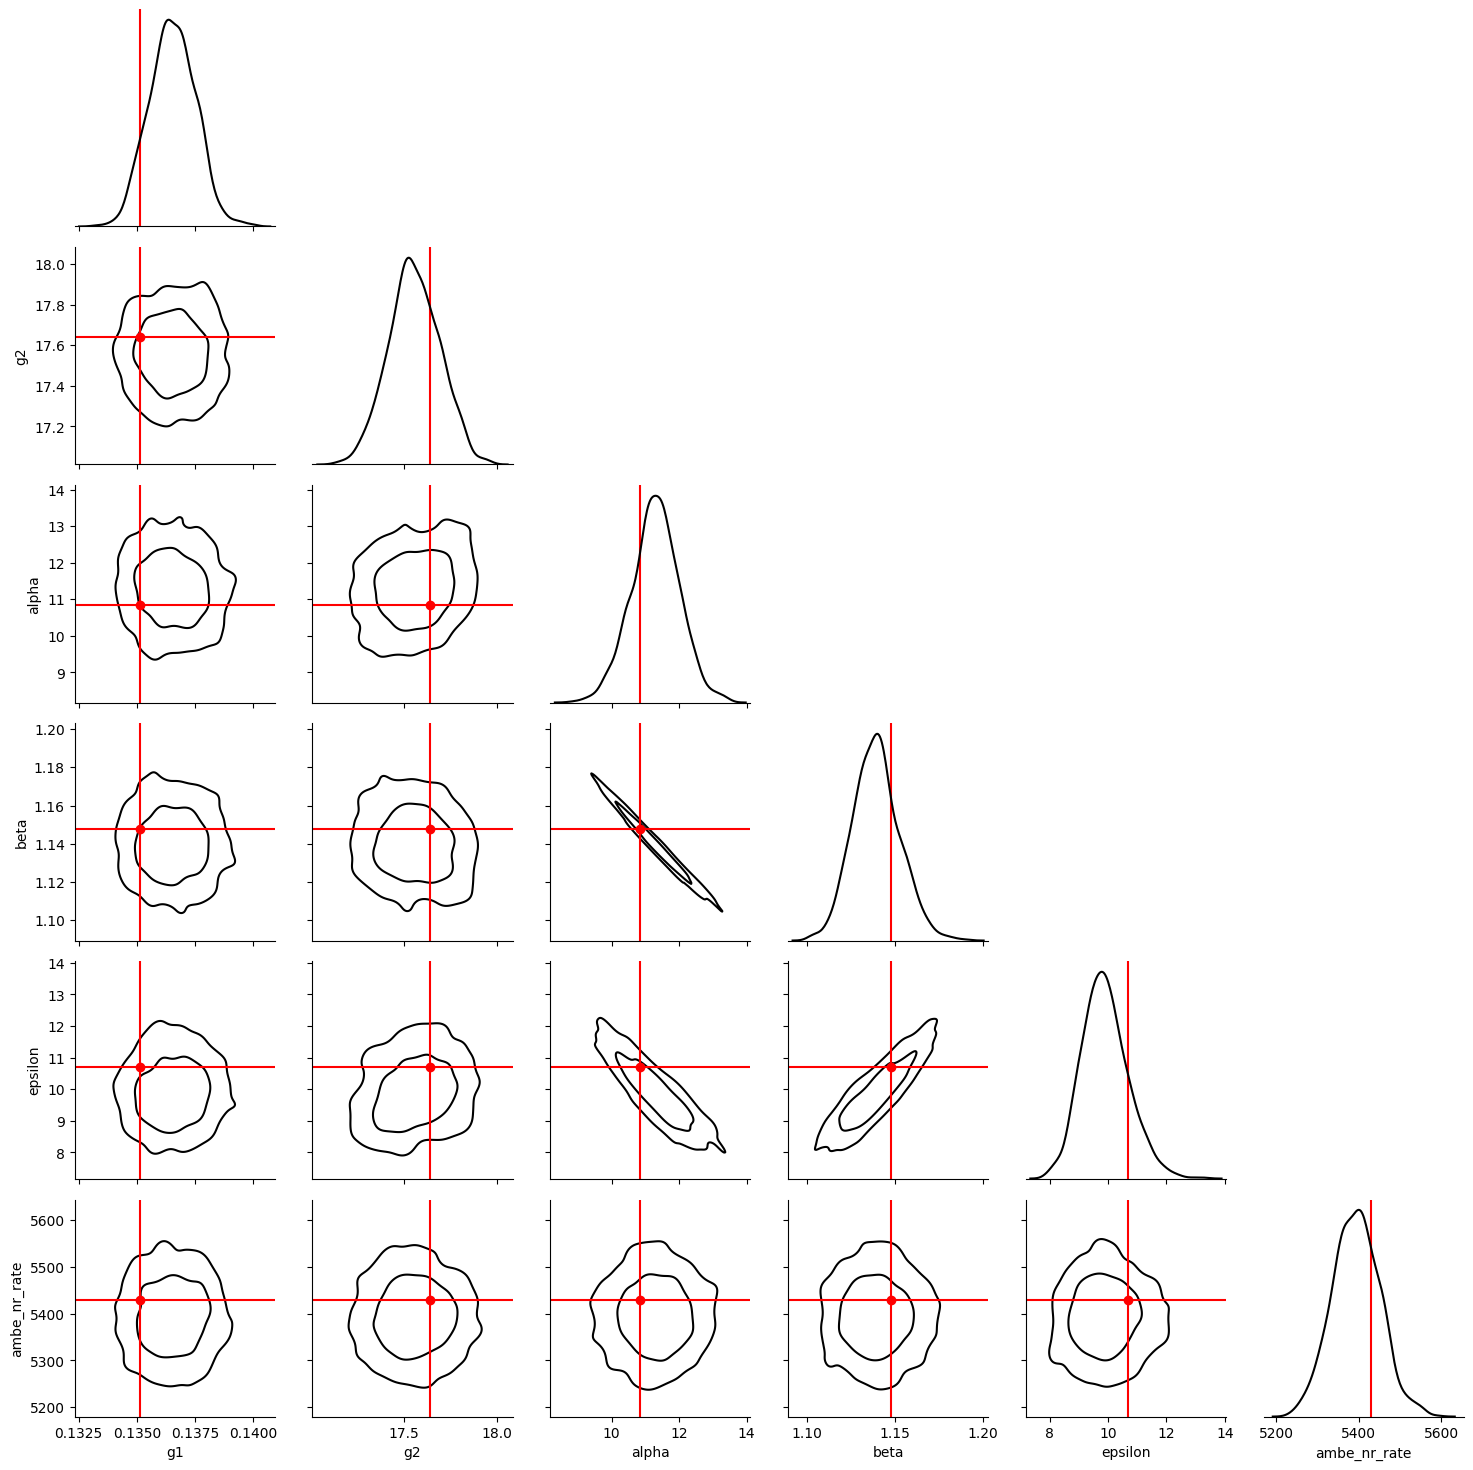

In [9]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names, out_dir=fbase,
)
fig = metric(posterior=posterior, x_obs=x_obs, theta_fid=y_true)

100%|██████████| 1000/1000 [00:59<00:00, 16.76it/s]
INFO:root:Saving coverage plot to /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/500totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau/plot_coverage.jpg...
INFO:root:Saving ranks histogram to /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/500totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau/ranks_histogram.jpg...
100%|██████████| 100/100 [00:14<00:00,  6.88it/s]


[<Figure size 2400x400 with 6 Axes>,
 <Figure size 1800x400 with 6 Axes>,
 <Figure size 2400x400 with 6 Axes>,
 <Figure size 400x400 with 1 Axes>]

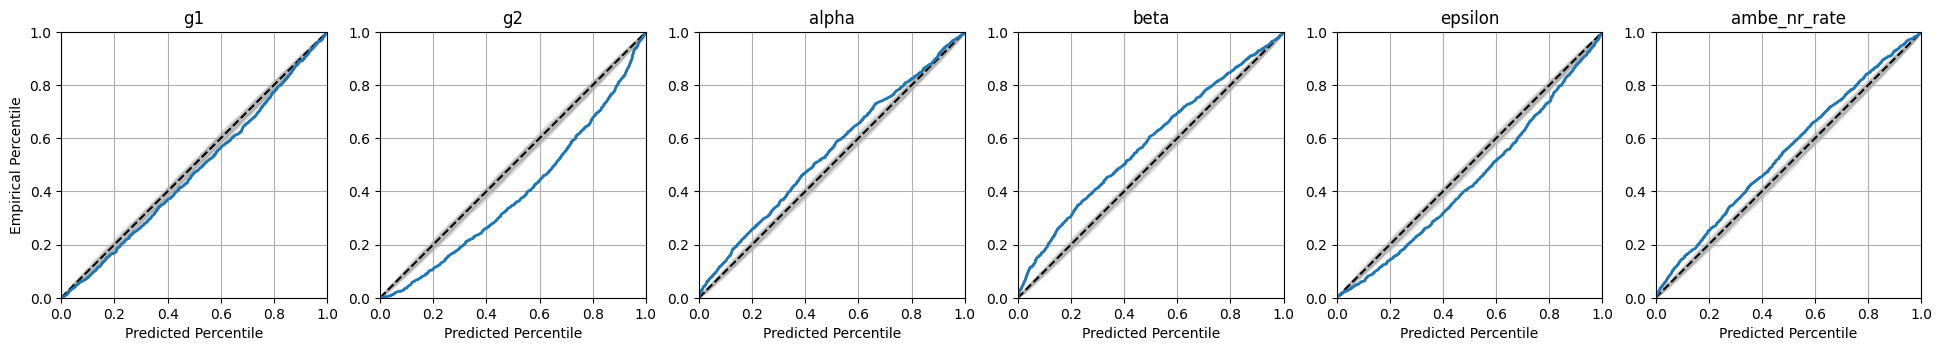

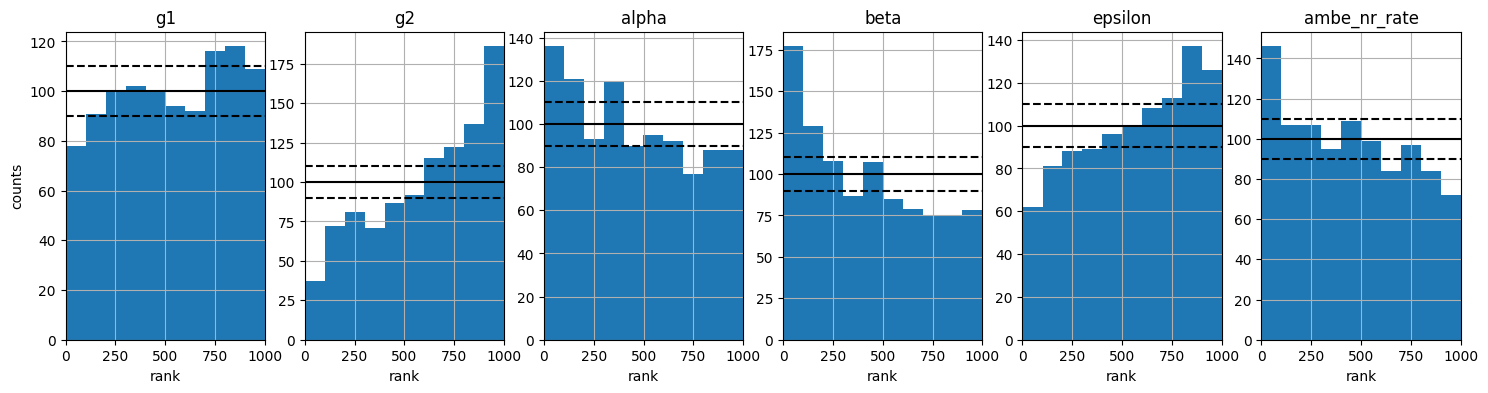

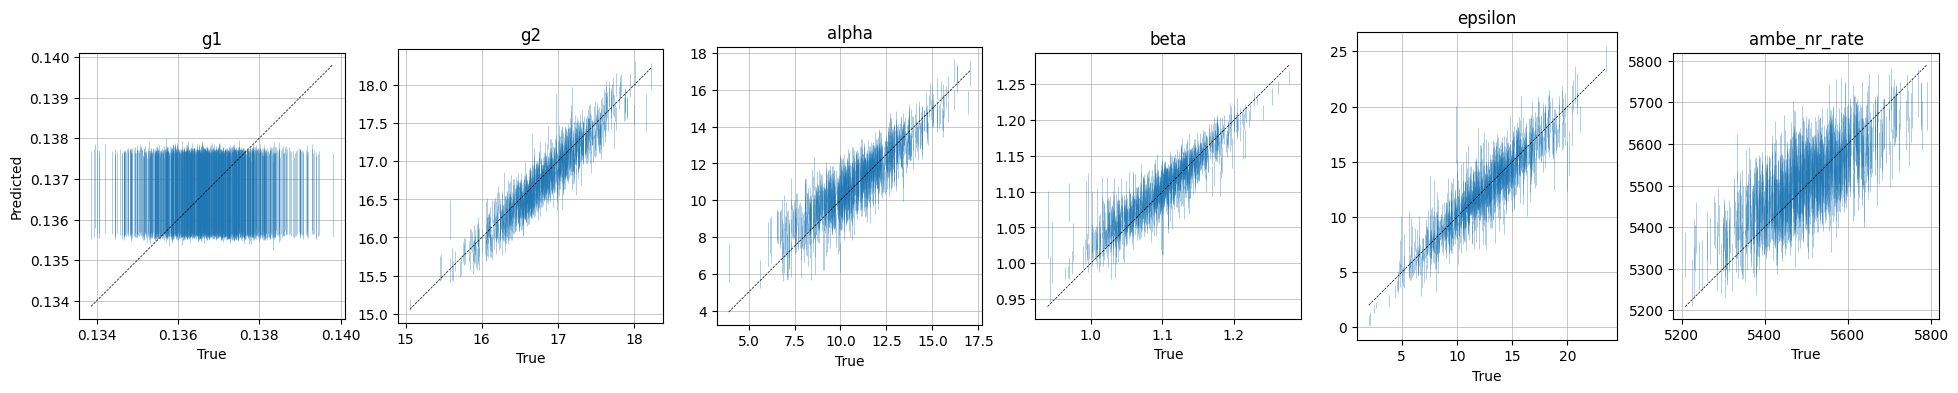

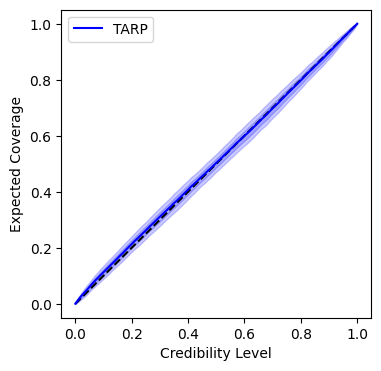

In [10]:
metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=fbase, labels=param_names,
    plot_list=['coverage', # PP plots
               'predictions', # pred vs truth
               'tarp', # posterior coverage??
               'histogram'], # uhhh
    save_samples=False,
)
metric(posterior=posterior, x=test_graph, theta=theta_test)